In [1]:
from ultralytics import YOLO
import torch

In [2]:
# Verify the GPU is detected
if torch.cuda.is_available():
    print(f"GPU Engine Started: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CUDA not found, CPU will be incredibly slow.")

GPU Engine Started: NVIDIA GeForce RTX 4060


In [2]:
# Yolo Nano Models
models = [
    "yolov8n.pt",  
    "yolov10n.pt",  
    "yolo11n.pt",
    "yolo26n.pt",
    "mnv4_small.yaml",
    "mnv4_medium.yaml"
]

In [4]:
for model_name in models:
    print(f"\n{'='*50}")
    print(f"STARTING TRAINING: {model_name}")
    print(f"{'='*50}\n")
    
    # Load the specific architecture
    model = YOLO(model_name)
    
    # Train the model
    results = model.train(
        data="data.yaml",               # The GPS for your dataset
        epochs=150,                     # 100 is the sweet spot for 2000 images
        seed=42,                        # For reproducibility
        deterministic=True,             # Ensure deterministic results
        imgsz=640,                      # Standard input resolution
        optimizer='AdamW',
        device=0,                       # Force use of GPU 0
        project="Sign_Detection",       # Main folder for results
        name=model_name.split('.')[0],  # Subfolder
        patience=30,                    # Early stopping if mAP stops improving
        batch=32                        # Safe batch size for an 8GB VRAM card
    )
    
    print(f"Finished training {model_name}\n")


STARTING TRAINING: yolov8n.pt

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.32 🚀 Python-3.10.20 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 7797MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale

/home/zuru-ubuntu/miniconda3/envs/chan_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4522.8±2290.1 MB/s, size: 403.6 KB)
val: Scanning /home/zuru-ubuntu/Documents/Chan/visual-sign-based-localization/1_data_augmentation/split_dataset/labels/val... 983 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 983/983 4.5Kit/s 0.2s0.0s
val: New cache created: /home/zuru-ubuntu/Documents/Chan/visual-sign-based-localization/1_data_augmentation/split_dataset/labels/val.cache
optimizer: AdamW(lr=0.01, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to /home/zuru-ubuntu/Documents/Chan/visual-sign-based-localization/2_sign_detection/runs/detect/Sign_Detection/yolov8n/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/zuru-ubuntu/Documents/Chan/visual-sign-based-localization/2_sign_detection/runs/detect/Sign_Detection/yolov8n
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
PROJECT_DIR = Path("runs/detect/Sign_Detection")
all_results = {}

# Recursive Data Loading
csv_files = list(PROJECT_DIR.glob("**/results.csv"))

for csv_path in csv_files:
    model_name = csv_path.parent.name
    try:
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]
        all_results[model_name] = df
    except Exception as e:
        print(f"Error loading {model_name}: {e}")

# Synthesis for Bar Charts
summary_data = []
for name, df in all_results.items():
    if not df.empty and 'metrics/mAP50-95(B)' in df.columns:
        best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()]
        summary_data.append({
            "Model": name,
            "Peak_mAP50": best_row['metrics/mAP50(B)'],
            "Peak_mAP50_95": best_row['metrics/mAP50-95(B)'],
            "Total_Time_Min": df['time'].sum() / 60 if 'time' in df.columns else 0,
            "Final_Val_Loss": df['val/box_loss'].iloc[-1]
        })

df_summary = pd.DataFrame(summary_data).sort_values("Peak_mAP50_95", ascending=False)
sns.set_style("whitegrid")
print(f"Processed {len(all_results)} models.")

Processed 6 models.


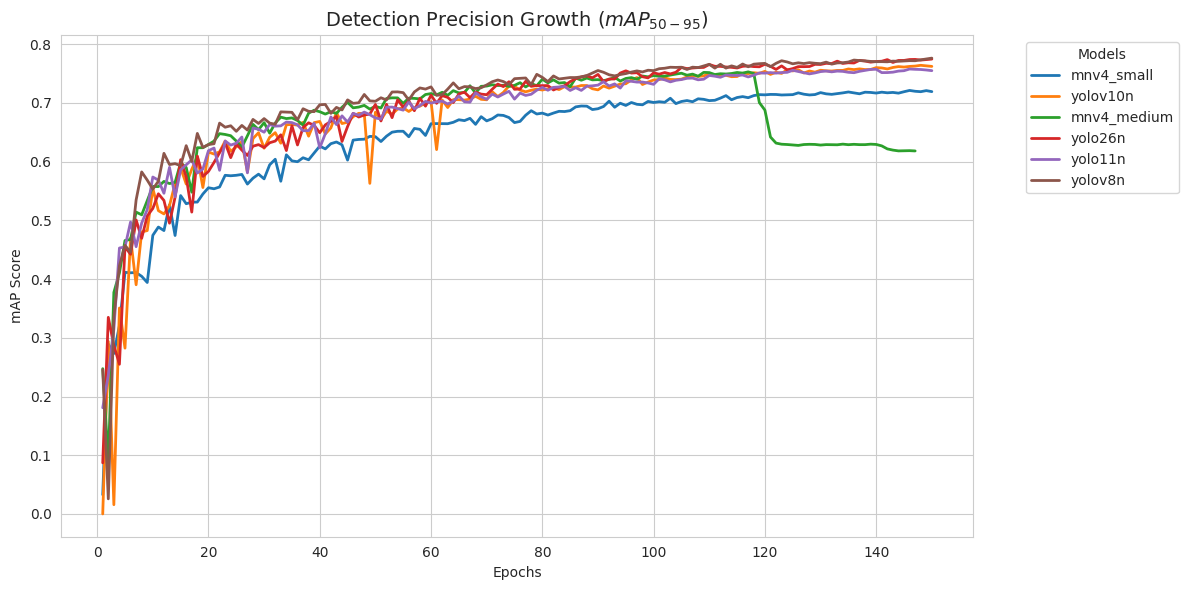

In [14]:
plt.figure(figsize=(12, 6))
for name, df in all_results.items():
    plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label=name, linewidth=2)

plt.title('Detection Precision Growth ($mAP_{50-95}$)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('mAP Score')
plt.legend(title="Models", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8739/1104058162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_summary, x="Model", y="Peak_mAP50_95", palette="viridis")


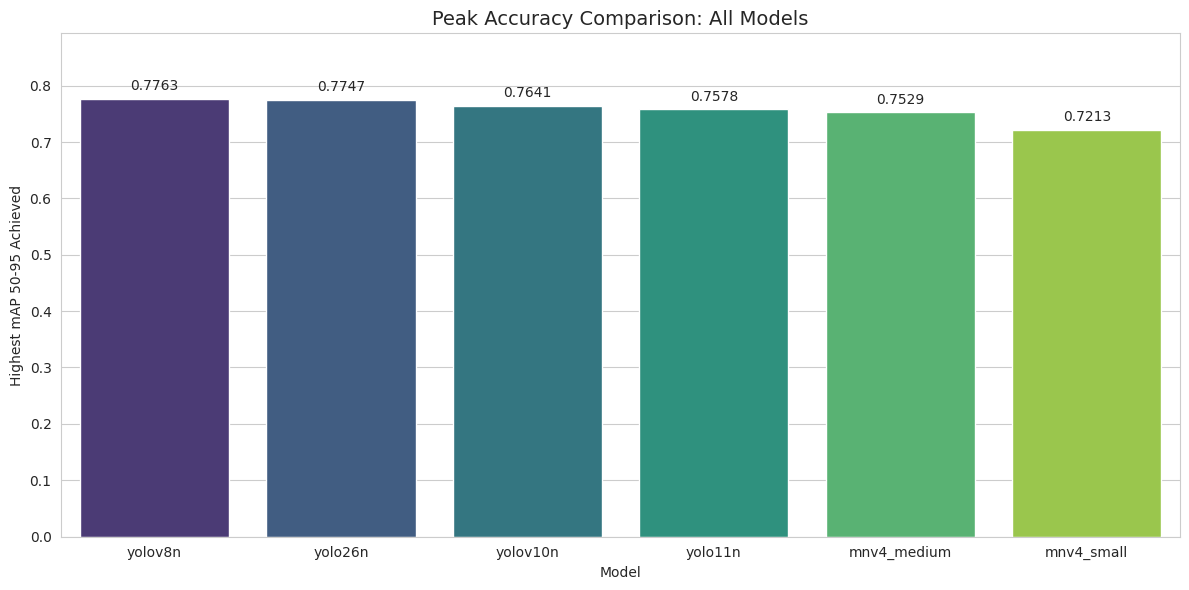

In [18]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_summary, x="Model", y="Peak_mAP50_95", palette="viridis")

plt.title('Peak Accuracy Comparison: All Models', fontsize=14)
plt.ylabel('Highest mAP 50-95 Achieved')
plt.ylim(0, max(df_summary['Peak_mAP50_95']) * 1.15)

# Annotate bars with exact values
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

/tmp/ipykernel_8739/2096451391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_time, x="Model", y="Total_Time_Min", palette="magma")


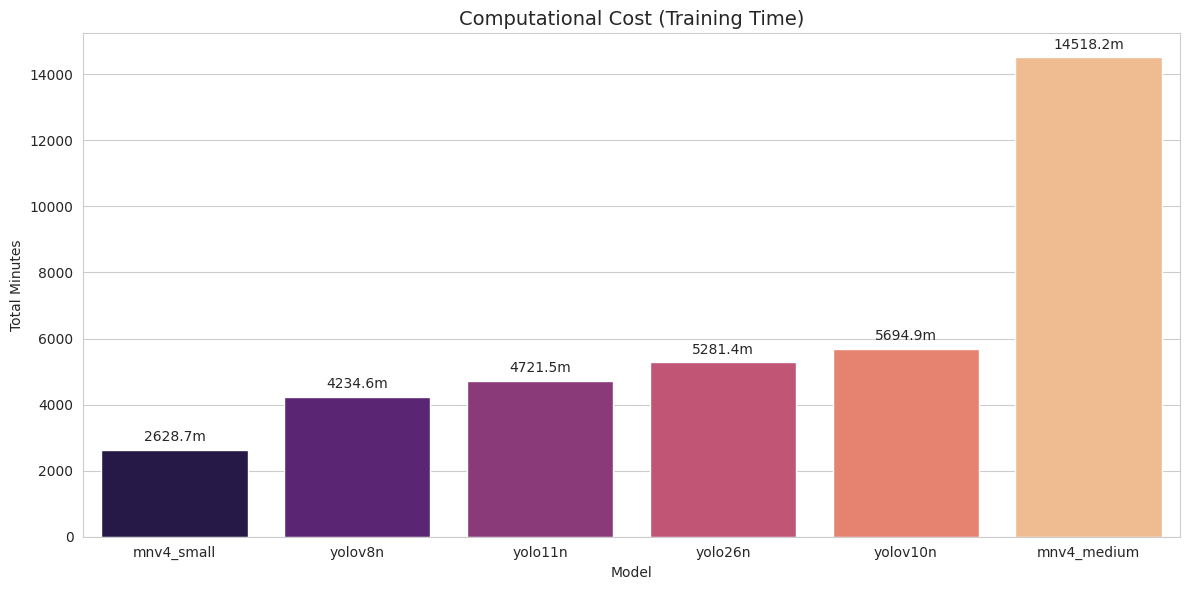

In [16]:
plt.figure(figsize=(12, 6))
# Sort by time for better visualization
df_time = df_summary.sort_values("Total_Time_Min")
ax = sns.barplot(data=df_time, x="Model", y="Total_Time_Min", palette="magma")

plt.title('Computational Cost (Training Time)', fontsize=14)
plt.ylabel('Total Minutes')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}m", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

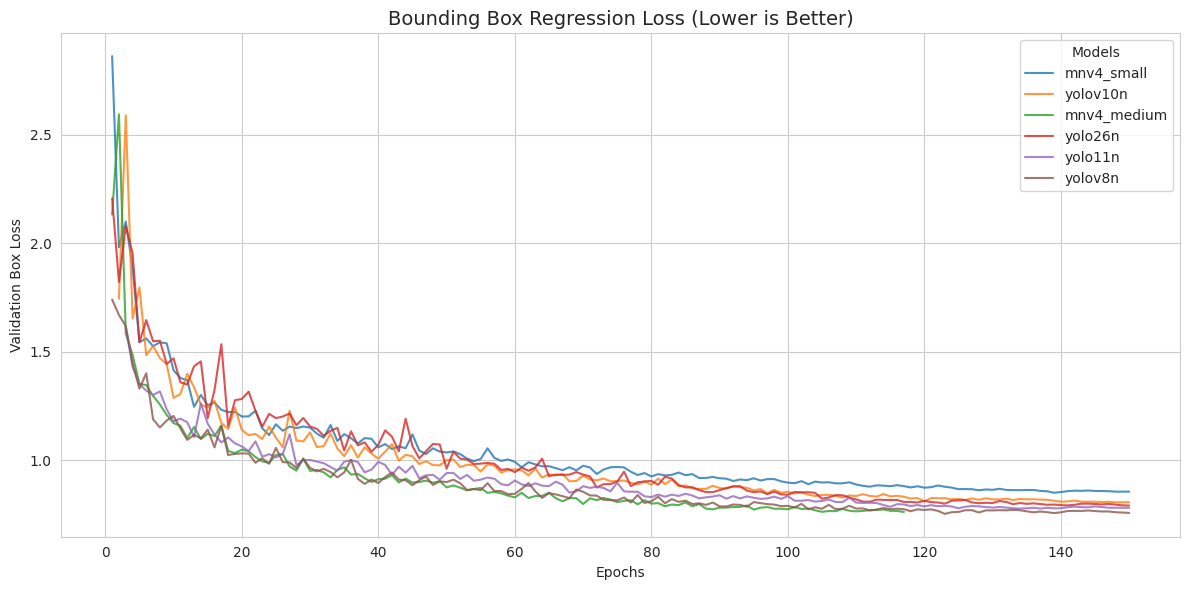

In [19]:
plt.figure(figsize=(12, 6))
for name, df in all_results.items():
    plt.plot(df['epoch'], df['val/box_loss'], label=name, alpha=0.8)

plt.title('Bounding Box Regression Loss (Lower is Better)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Validation Box Loss')
plt.legend(title="Models")
plt.tight_layout()
plt.show()

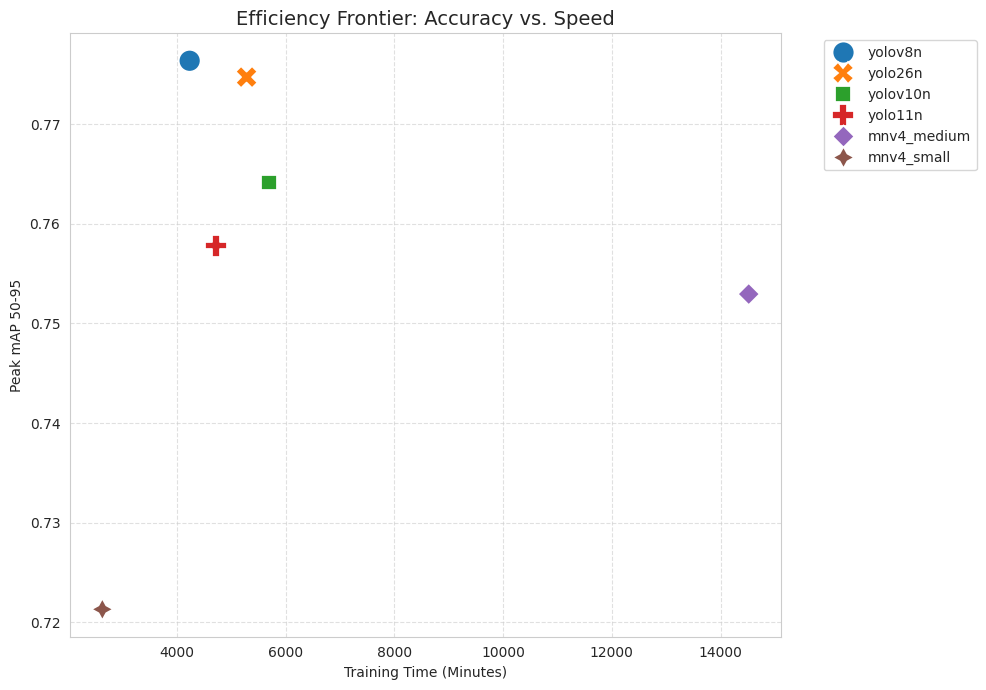

In [20]:
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(data=df_summary, x="Total_Time_Min", y="Peak_mAP50_95", 
                        hue="Model", s=250, style="Model")

plt.title('Efficiency Frontier: Accuracy vs. Speed', fontsize=14)
plt.xlabel('Training Time (Minutes)')
plt.ylabel('Peak mAP 50-95')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
from IPython.display import display

def generate_final_leaderboard(all_results):
    comparison_data = []

    for name, df in all_results.items():
        # 1. Accuracy Metrics (Peak Performance)
        peak_map50 = df['metrics/mAP50(B)'].max()
        peak_map95 = df['metrics/mAP50-95(B)'].max()
        
        # 2. Efficiency Metrics
        total_train_time = df['time'].sum() / 60  # Minutes
        avg_epoch_time = df['time'].mean()       # Seconds
        
        # 3. Training Progress
        final_epoch = df['epoch'].max()
        
        # 4. Stability (Final Validation Loss)
        # Lower box loss means better bounding box precision
        final_box_loss = df['val/box_loss'].iloc[-1]

        comparison_data.append({
            "Model Architecture": name,
            "mAP@50 (Peak)": peak_map50,
            "mAP@50-95 (Peak)": peak_map95,
            "Total Time (Min)": total_train_time,
            "Sec/Epoch": avg_epoch_time,
            "Final Box Loss": final_box_loss,
            "Epochs": final_epoch
        })

    # Create DataFrame and sort by the most difficult metric (mAP 50-95)
    report_df = pd.DataFrame(comparison_data).sort_values(by="mAP@50-95 (Peak)", ascending=False)
    
    # Apply styling: Green is good for Accuracy, Red is 'higher/worse' for Loss and Time
    styled_report = report_df.style.background_gradient(cmap='Greens', subset=['mAP@50 (Peak)', 'mAP@50-95 (Peak)']) \
                                    .background_gradient(cmap='Reds', subset=['Total Time (Min)', 'Final Box Loss']) \
                                    .format({
                                        "mAP@50 (Peak)": "{:.4f}",
                                        "mAP@50-95 (Peak)": "{:.4f}",
                                        "Total Time (Min)": "{:.1f}",
                                        "Sec/Epoch": "{:.1f}",
                                        "Final Box Loss": "{:.4f}"
                                    })
    return styled_report

# Execute
if all_results:
    final_table = generate_final_leaderboard(all_results)
    display(final_table)
else:
    print("No data found to generate the table.")

,Model Architecture,mAP@50 (Peak),mAP@50-95 (Peak),Total Time (Min),Sec/Epoch,Final Box Loss,Epochs
5,yolov8n,0.9747,0.7763,4234.6,1693.8,0.7583,150
3,yolo26n,0.9700,0.7747,5281.4,2112.5,0.7923,150
1,yolov10n,0.9648,0.7641,5694.9,2278.0,0.8074,150
4,yolo11n,0.9615,0.7578,4721.5,1888.6,0.7818,150
2,mnv4_medium,0.9506,0.7529,14518.2,5925.8,nan,147
0,mnv4_small,0.9504,0.7213,2628.7,1051.5,0.8566,150
